In [1]:
!pip install sentencepiece

## Импорты, фиксация seed, выбор device

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from datasets import load_dataset
import sentencepiece as spm
import numpy as np
import math
import os
import random
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import gc

warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


## Загрузка WMT19

In [17]:
dataset = load_dataset("wmt19", "ru-en", split="train[:500_000]")
val_dataset = load_dataset("wmt19", "ru-en", split="validation[:50_000]")

print(f"Train samples: {len(dataset)}")
print(f"Val samples: {len(val_dataset)}")

en_texts = [item['translation']['en'] for item in dataset]
ru_texts = [item['translation']['ru'] for item in dataset]

with open("bpe_train.en", "w", encoding="utf-8") as f:
    for line in en_texts:
        f.write(line.replace('\n', ' ') + '\n')

with open("bpe_train.ru", "w", encoding="utf-8") as f:
    for line in ru_texts:
        f.write(line.replace('\n', ' ') + '\n')

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Train samples: 500000
Val samples: 3000


In [4]:
%cp /kaggle/input/data-dl-6/* /kaggle/working/

## Загрузка токенайзера

In [5]:
sp_en = spm.SentencePieceProcessor()
sp_en.load('bpe_en (2).model')
sp_ru = spm.SentencePieceProcessor()
sp_ru.load('bpe_ru (2).model')

print(f"English vocab size: {sp_en.get_piece_size()}")
print(f"Russian vocab size: {sp_ru.get_piece_size()}")

English vocab size: 32000
Russian vocab size: 32000


## BPE-токенизация, паддинг, формирование обучающей и валидационной выборки.

In [6]:
class BPEDataset(Dataset):
    def __init__(self, data, src_sp, trg_sp, max_len=80):
        self.data = data
        self.src_sp = src_sp
        self.trg_sp = trg_sp
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]['translation']

        src_ids = [1] + self.src_sp.encode(item['en'], out_type=int)[:self.max_len-2] + [2]
        trg_ids = [1] + self.trg_sp.encode(item['ru'], out_type=int)[:self.max_len-2] + [2]

        # Padding до max_len
        src_ids += [0] * (self.max_len - len(src_ids))
        trg_ids += [0] * (self.max_len - len(trg_ids))

        return torch.tensor(src_ids), torch.tensor(trg_ids)


train_dataset = BPEDataset(dataset, sp_en, sp_ru, max_len=80)
val_dataset_obj = BPEDataset(val_dataset, sp_en, sp_ru, max_len=80)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset_obj,
    batch_size=128
)

## Mamba2Block + RMSNorm + SSD Kernels

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        norm = x.pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return x * norm * self.weight


def mamba2_ssd_parallel(x, dt, A, B, C):
    B_batch, L, H, P = x.shape
    N = B.shape[-1]
    device = x.device

    x = x.float()
    dt = dt.float()
    A = A.float()
    B = B.float()
    C = C.float()

    dt_A = dt * A.view(1, 1, H)

    cumsum = torch.cumsum(dt_A, dim=1)

    diff = cumsum.unsqueeze(2) - cumsum.unsqueeze(1)

    causal_mask = torch.tril(torch.ones(L, L, device=device, dtype=torch.bool))
    diff = diff.masked_fill(~causal_mask.view(1, L, L, 1), -float('inf'))

    L_matrix = torch.exp(diff)
    scores = torch.einsum('bihk,bjhk->bijh', C, B)

    scores = scores * L_matrix * dt.unsqueeze(1)

    y = torch.einsum('bijh,bjhp->bihp', scores, x)

    return y


def mamba2_ssd_recurrent(x, dt, A, B, C):
    B_batch, L, H, P = x.shape
    N = B.shape[-1]
    device = x.device
    dtype = x.dtype

    h = torch.zeros(B_batch, H, N, P, device=device, dtype=torch.float32)

    x = x.float()
    dt = dt.float()
    A = A.float()
    B = B.float()
    C = C.float()

    outputs = []

    for t in range(L):
        decay = torch.exp(A.view(1, H) * dt[:, t, :])
        decay = decay.view(B_batch, H, 1, 1)

        Bx = torch.einsum('bhn,bhp->bhnp', B[:, t], x[:, t])
        h = decay * h + dt[:, t, :].view(B_batch, H, 1, 1) * Bx

        y_t = torch.einsum('bhn,bhnp->bhp', C[:, t], h)
        outputs.append(y_t)

    return torch.stack(outputs, dim=1).to(dtype)


class Mamba2Block(nn.Module):
    def __init__(self, d_model, d_state=64, d_conv=4, n_heads=8, expand=2):
        super().__init__()

        self.d_model = d_model
        self.d_state = d_state
        self.n_heads = n_heads
        self.expand = expand
        self.d_inner = d_model * expand
        self.d_head = self.d_inner // n_heads

        assert self.d_inner % n_heads == 0

        self.proj_size = 2 * self.d_inner + 2 * n_heads * d_state + n_heads
        self.in_proj = nn.Linear(d_model, self.proj_size, bias=False)

        self.conv1d = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, groups=self.d_inner,
            padding=d_conv - 1, bias=True
        )

        A_init = torch.arange(1, n_heads + 1, dtype=torch.float32)
        self.A_log = nn.Parameter(torch.log(A_init))

        self.dt_bias = nn.Parameter(torch.zeros(n_heads).uniform_(-4.0, -3.0))

        self.D = nn.Parameter(torch.ones(n_heads))

        self.norm = RMSNorm(self.d_inner)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward(self, u, inference_mode=False):

        B, L, _ = u.shape

        proj = self.in_proj(u)

        x = proj[..., :self.d_inner]
        z = proj[..., self.d_inner:2*self.d_inner]
        B_proj = proj[..., 2*self.d_inner:2*self.d_inner + self.n_heads*self.d_state]
        C_proj = proj[..., 2*self.d_inner + self.n_heads*self.d_state:
                        2*self.d_inner + 2*self.n_heads*self.d_state]
        dt_proj = proj[..., -self.n_heads:]

        x_conv = self.conv1d(x.transpose(1, 2))[..., :L].transpose(1, 2)
        x_conv = F.silu(x_conv)

        x_heads = x_conv.view(B, L, self.n_heads, self.d_head)
        B_heads = B_proj.view(B, L, self.n_heads, self.d_state)
        C_heads = C_proj.view(B, L, self.n_heads, self.d_state)

        dt = F.softplus(dt_proj + self.dt_bias)

        A = -torch.exp(self.A_log)

        with torch.cuda.amp.autocast(enabled=False):
            if inference_mode:
                y = mamba2_ssd_recurrent(x_heads, dt, A, B_heads, C_heads)
            else:
                y = mamba2_ssd_parallel(x_heads, dt, A, B_heads, C_heads)

        y = y + x_heads * self.D.view(1, 1, self.n_heads, 1)

        y = y.reshape(B, L, self.d_inner)

        out = self.norm(y) * F.silu(z)

        return self.out_proj(out.to(u.dtype))


## Энкодер, декодер с cross-attention и полный Seq2Seq модельный класс.

In [8]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Mamba2BlockBidirectional(nn.Module):
    def __init__(self, d_model, d_state=64, d_conv=4, n_heads=8, expand=2):
        super().__init__()
        self.mamba_fwd = Mamba2Block(d_model, d_state, d_conv, n_heads, expand)
        self.mamba_bwd = Mamba2Block(d_model, d_state, d_conv, n_heads, expand)

    def forward(self, x):
        y_fwd = self.mamba_fwd(x)

        x_rev = torch.flip(x, dims=[1])
        y_bwd = self.mamba_bwd(x_rev)
        y_bwd = torch.flip(y_bwd, dims=[1])

        return y_fwd + y_bwd


class Mamba2EncoderLayer(nn.Module):
    def __init__(self, d_model, d_state=64, n_heads=8, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.mamba = Mamba2BlockBidirectional(d_model, d_state, n_heads=n_heads)
        self.norm2 = RMSNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.mamba(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class Mamba2Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, d_state=64, n_heads=8, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, dropout=dropout)
        self.embed_scale = math.sqrt(d_model)

        self.layers = nn.ModuleList([
            Mamba2EncoderLayer(d_model, d_state, n_heads, dropout)
            for _ in range(n_layers)
        ])
        self.norm = RMSNorm(d_model)

    def forward(self, src, src_mask=None):
        x = self.embedding(src) * self.embed_scale
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x)

        return self.norm(x)

class CrossAttention(nn.Module):
    def __init__(self, d_model, n_heads=8, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.scale = self.d_head ** -0.5

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, context, context_mask=None):
        B, L_dec, D = x.shape
        L_enc = context.shape[1]
        q = self.q_proj(x).view(B, L_dec, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k_proj(context).view(B, L_enc, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(context).view(B, L_enc, self.n_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale

        if context_mask is not None:
            mask = context_mask.view(B, 1, 1, L_enc)
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(B, L_dec, D)

        return self.out_proj(out)


class Mamba2DecoderLayer(nn.Module):
    def __init__(self, d_model, d_state=64, n_heads=8, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.mamba = Mamba2Block(d_model, d_state=d_state, n_heads=n_heads)
        self.norm2 = RMSNorm(d_model)
        self.cross_attn = CrossAttention(d_model, n_heads=n_heads, dropout=dropout)
        self.norm3 = RMSNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x, encoder_out, encoder_mask=None, inference_mode=False):
        x = x + self.mamba(self.norm1(x), inference_mode=inference_mode)
        x = x + self.cross_attn(self.norm2(x), encoder_out, encoder_mask)
        x = x + self.ffn(self.norm3(x))
        return x


class Mamba2Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, d_state=64, n_heads=8, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, dropout=dropout)

        self.embed_scale = math.sqrt(d_model)

        self.layers = nn.ModuleList([
            Mamba2DecoderLayer(d_model, d_state, n_heads, dropout)
            for _ in range(n_layers)
        ])
        self.norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        self.lm_head.weight = self.embedding.weight

    def forward(self, trg, encoder_out, encoder_mask=None, inference_mode=False):
        x = self.embedding(trg) * self.embed_scale
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, encoder_out, encoder_mask, inference_mode)

        x = self.norm(x)
        return self.lm_head(x)


class Mamba2Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, d_model=256,
                 n_layers=4, d_state=64, n_heads=8, dropout=0.1):
        super().__init__()

        self.encoder = Mamba2Encoder(
            src_vocab_size, d_model, n_layers, d_state, n_heads, dropout
        )
        self.decoder = Mamba2Decoder(
            trg_vocab_size, d_model, n_layers, d_state, n_heads, dropout
        )

        self.d_model = d_model
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1 and 'embedding' not in name:
                nn.init.xavier_uniform_(p, gain=0.5)
            elif 'embedding' in name:
                nn.init.normal_(p, std=0.02)

    def forward(self, src, trg, src_mask=None):
        encoder_out = self.encoder(src, src_mask)
        logits = self.decoder(trg, encoder_out, src_mask)
        return logits

    def encode(self, src, src_mask=None):
        return self.encoder(src, src_mask)

    def decode_step(self, trg, encoder_out, src_mask=None):
        return self.decoder(trg, encoder_out, src_mask, inference_mode=True)


# Инициализация модели

In [9]:
CONFIG = {
    'd_model': 296,
    'n_layers': 4,
    'd_state': 64,
    'n_heads': 8,
    'dropout': 0.1
}

model = Mamba2Seq2Seq(
    src_vocab_size=sp_en.get_piece_size(),
    trg_vocab_size=sp_ru.get_piece_size(),
    **CONFIG
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")




Total parameters: 35,988,560
Trainable parameters: 35,988,560


## Создание маски, декод токенов и генерация перевода с автопадом и температурой

In [10]:
def create_src_mask(src):
    return (src != 0).float()


def decode_tokens(tokens, sp):
    filtered = []
    for t in tokens:
        if t == 0:  # PAD
            continue
        if t == 2:  # EOS
            break
        if t == 1:  # BOS
            continue
        filtered.append(int(t))
    return sp.decode(filtered) if filtered else ""


@torch.no_grad()
def translate(model, src_tensor, sp_ru, max_len=80, device='cuda', temperature=1.0):
    model.eval()

    if src_tensor.dim() == 1:
        src_tensor = src_tensor.unsqueeze(0)
    src_tensor = src_tensor.to(device)

    src_mask = create_src_mask(src_tensor)
    encoder_out = model.encode(src_tensor, src_mask)

    generated = [1]

    for _ in range(max_len):
        trg_tensor = torch.tensor(generated, device=device).unsqueeze(0)
        logits = model.decode_step(trg_tensor, encoder_out, src_mask)

        next_logits = logits[0, -1, :] / temperature

        if temperature == 1.0:
            next_token = next_logits.argmax().item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, 1).item()

        if next_token == 2:
            break

        generated.append(next_token)

    return sp_ru.decode(generated[1:])


def translate_sentence(model, sentence, sp_en, sp_ru, device='cuda'):
    tokens = [1] + sp_en.encode(sentence, out_type=int)[:62] + [2]
    src_tensor = torch.tensor(tokens, dtype=torch.long)
    return translate(model, src_tensor, sp_ru, device=device)


## AdamW, CrossEntropy, градиентный скейлер и функция валидации с примерами перевода.


In [11]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.01,
    betas=(0.9, 0.98),
    eps=1e-9
)

def get_lr(step, warmup_steps=3000, max_lr=5e-4, min_lr=1e-5):
    if step < warmup_steps:
        return max_lr * step / warmup_steps
    else:
        decay_steps = 50000
        progress = min((step - warmup_steps) / decay_steps, 1.0)
        return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

scaler = GradScaler()


def evaluate(model, loader, criterion, device, sp_en, sp_ru, num_examples=3):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            src_mask = (src != 0).float()

            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]

            with autocast():
                logits = model(src, trg_input, src_mask)
                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    trg_output.reshape(-1)
                )
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    
    print(f"\n{'='*50}")
    print(f"Validation Loss: {avg_loss:.4f} | PPL: {math.exp(avg_loss):.2f}")
    print(f"{'='*50}")

    dataset = loader.dataset
    indices = random.sample(range(len(dataset)), min(num_examples, len(dataset)))

    for idx in indices:
        src, trg = dataset[idx]

        src_text = decode_tokens(src.tolist(), sp_en)
        ref_text = decode_tokens(trg.tolist(), sp_ru)
        pred_text = translate(model, src, sp_ru, device=device)

        print(f"\n[EN]  {src_text[:100]}")
        print(f"[REF] {ref_text[:100]}")
        print(f"[HYP] {pred_text[:100]}")

    return avg_loss



## Обучение

In [13]:
NUM_EPOCHS = 20
global_step = 0
best_val_loss = float('inf')
patience = 3
no_improve = 0

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print(f"Batch size: {BATCH_SIZE}, Batches per epoch: {len(train_loader)}")

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for src, trg in pbar:
        src, trg = src.to(device), trg.to(device)

        src_mask = (src != 0).float()

        trg_input = trg[:, :-1]
        trg_output = trg[:, 1:]

        lr = get_lr(global_step)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(src, trg_input, src_mask)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                trg_output.reshape(-1)
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        global_step += 1

        pbar.set_postfix({
            'loss': f'{loss.item():.3f}',
            'lr': f'{lr:.2e}',
            'gnorm': f'{grad_norm:.2f}'
        })
        
    gc.collect()
    torch.cuda.empty_cache()

    avg_train_loss = total_loss / len(train_loader)

    val_loss = evaluate(model, val_loader, criterion, device, sp_en, sp_ru)

    gc.collect()
    torch.cuda.empty_cache()


    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'config': CONFIG
        }, 'best_mamba2_model.pth')
        print(f"Saved best model!")
        no_improve = 0
    else:
        no_improve += 1
        print(f"No improvement for {no_improve} epochs")

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break



Starting training for 20 epochs...
Batch size: 128, Batches per epoch: 3907


Epoch 1/20: 100%|██████████| 3907/3907 [35:01<00:00,  1.86it/s, loss=4.717, lr=5.00e-04, gnorm=1.58]



Validation Loss: 6.1058 | PPL: 448.43

[EN]  A 17-year-old Russian national who scaled the side of a skyscraper has been detained in Mexico
[REF] В Мексике задержан забравшийся по стене на небоскреб 17-летний россиянин
[HYP] В 17-лет-го годы, в котором в 17 раз в рамках этого года, в рамках которого в области реформ, в обла

[EN]  We are aware of 20 fatalities.
[REF] Известно о 20 погибших.
[HYP] Мы знаем, что в 20 с 20 с 20 с 20 с 20 с 20 с 20 с 20 с 20 лет.

[EN]  For example, chewing gum is only sold in pharmacies, and it can only by bought with a doctor’s presc
[REF] Например, жевательная резинка продается только в аптеках, и купить ее можно строго по рецепту (!) вр
[HYP] Например, в том случае, в случае, в то время, в то время, в то время, в то время, в то же случае, в 

Epoch 1 Summary:
  Train Loss: 6.1163
  Val Loss:   6.1058
  ✓ Saved best model!


Epoch 2/20: 100%|██████████| 3907/3907 [35:02<00:00,  1.86it/s, loss=3.308, lr=4.89e-04, gnorm=2.06]



Validation Loss: 5.2404 | PPL: 188.75

[EN]  The programme will cost  ⁇ 10 million and NHS England signed a contract to source the drugs this wee
[REF] Программа будет стоить 10 миллионов фунтов, и Национальная служба здравоохранения Англии на этой нед
[HYP] В программу будет подписано стоимость  ⁇ 10 млн. и NHH Англии подписано договор в качестве него, что

[EN]  Currently, foreigners are prohibited from holding a position in the municipal service or being emplo
[REF] Сейчас иностранцам запрещено занимать должности на муниципальной службе, быть принятыми на работу на
[HYP] В настоящее время иностранцев запрещают позиции в муниципальном сервисе или в целях обеспечения и в 

[EN]  The Comandante Borsini patrol ship entered Libya’s territorial waters so as to then stop the flow of
[REF] Патрульный корабль "Команданте Борсини" вошел в территориальные воды Ливии, чтобы затем вместе с ВМС
[HYP] В этом году, как и в этом году, в стране, в стране, в стране, в стране, в стране, в стране, в ст

...


Validation Loss: 4.5072 | PPL: 90.67

[EN]  Did I go too hard?
[REF] Я переигрываю?
[HYP] Не устал ли я слишком тяжело?

[EN]  One of the best academic chamber orchestras, Musica Viva, will try its hand in a new format, under t
[REF] В новом качестве попробует себя один из лучших академических камерных оркестров "Музыка Вива" под ру
[HYP] Один из лучших академических камер, или оркестра, Музыкана, пробудит свою руку в новом формате, под 

[EN]  The preliminary diagnosis is a serious allergic reaction.
[REF] Предварительный диагноз - серьезная аллергическая реакция.
[HYP] предварительная диагностика является серьезной аллергической реакцией.

Epoch 12 Summary:
  Train Loss: 2.8102
  Val Loss:   4.5072
  No improvement for 1 epochs


Epoch 13/20: 100%|██████████| 3907/3907 [34:55<00:00,  1.86it/s, loss=2.594, lr=1.24e-05, gnorm=2.93]



Validation Loss: 4.5137 | PPL: 91.26

[EN]  According to the investigation, the child died because her mother is an HIV dissident and refused tr
[REF] Как утверждает следствие, ребенок погиб из-за того, что мать является ВИЧ-диссиденткой и отказывалас
[HYP] Согласно расследованию, ребенок умер, потому что ее мама является разочарованием ВИЧ и отказано в ле

[EN]  This trial will take us one step closer to fully understanding the benefits of PrEP.
[REF] Это испытание приблизит нас на шаг к полному пониманию преимуществ ПрЭП.
[HYP] Этот курс, который мы будем сходить друг к другу, ближе к полностью пониманию пользы ПЭП.

[EN]  It's difficult to watch, and even more difficult to look away, but Greene said that's the point.
[REF] Его трудно смотреть и еще труднее отвернуться, но Грин считает, что это и есть главное.
[HYP] Трудно смотреть, и еще более трудно смотреть, но зеленый сказал, что это то, что произошло.

Epoch 13 Summary:
  Train Loss: 2.7750
  Val Loss:   4.5137
  No improvement

Epoch 14/20: 100%|██████████| 3907/3907 [34:56<00:00,  1.86it/s, loss=2.756, lr=1.00e-05, gnorm=3.20]



Validation Loss: 4.5165 | PPL: 91.52

[EN]  Meanwhile, the Republican National Committee released a statement Thursday night saying "Governor Ju
[REF] Тем временем, Национальный комитет Республиканской партии в четверг вечером выпустил заявление, что 
[HYP] В это же время, что Республиканский национальный комитет выпустил заявление о том, что переключение 

[EN]  But no one has been able to consistently prevent Trump from stirring up controversy.
[REF] Но никому не удавалось всегда удерживать Трампа от подливания масла в огонь.
[HYP] Но никто не мог последовательно препятствовать тренуну от вскрытия разногласий.

[EN]  Indonesia has another presidential election in 2019, but Papuans say they are unlikely to vote again
[REF] В Индонезии в 2019 году состоятся новые президентские выборы, но папуасы говорят, что вряд ли снова 
[HYP] Индонезия имеет еще одного президентских выборов в 2019, но папуане говорят, что они пущены снова на

Epoch 14 Summary:
  Train Loss: 2.7576
  Val Loss:   4.5

In [13]:
checkpoint = torch.load("/kaggle/input/data-dl-6/best_mamba2_model.pth", map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


Mamba2Seq2Seq(
  (encoder): Mamba2Encoder(
    (embedding): Embedding(32000, 296, padding_idx=0)
    (pos_encoding): SinusoidalPositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-3): 4 x Mamba2EncoderLayer(
        (norm1): RMSNorm()
        (mamba): Mamba2BlockBidirectional(
          (mamba_fwd): Mamba2Block(
            (in_proj): Linear(in_features=296, out_features=2216, bias=False)
            (conv1d): Conv1d(592, 592, kernel_size=(4,), stride=(1,), padding=(3,), groups=592)
            (norm): RMSNorm()
            (out_proj): Linear(in_features=592, out_features=296, bias=False)
          )
          (mamba_bwd): Mamba2Block(
            (in_proj): Linear(in_features=296, out_features=2216, bias=False)
            (conv1d): Conv1d(592, 592, kernel_size=(4,), stride=(1,), padding=(3,), groups=592)
            (norm): RMSNorm()
            (out_proj): Linear(in_features=592, out_features=296, bias=False)
          )
       

## Визуализация и выводы

📥 INPUT (EN):      This is my house.
📤 MODEL OUTPUT:    Это мой дом.
✅ REFERENCE (RU):  Это мой дом.


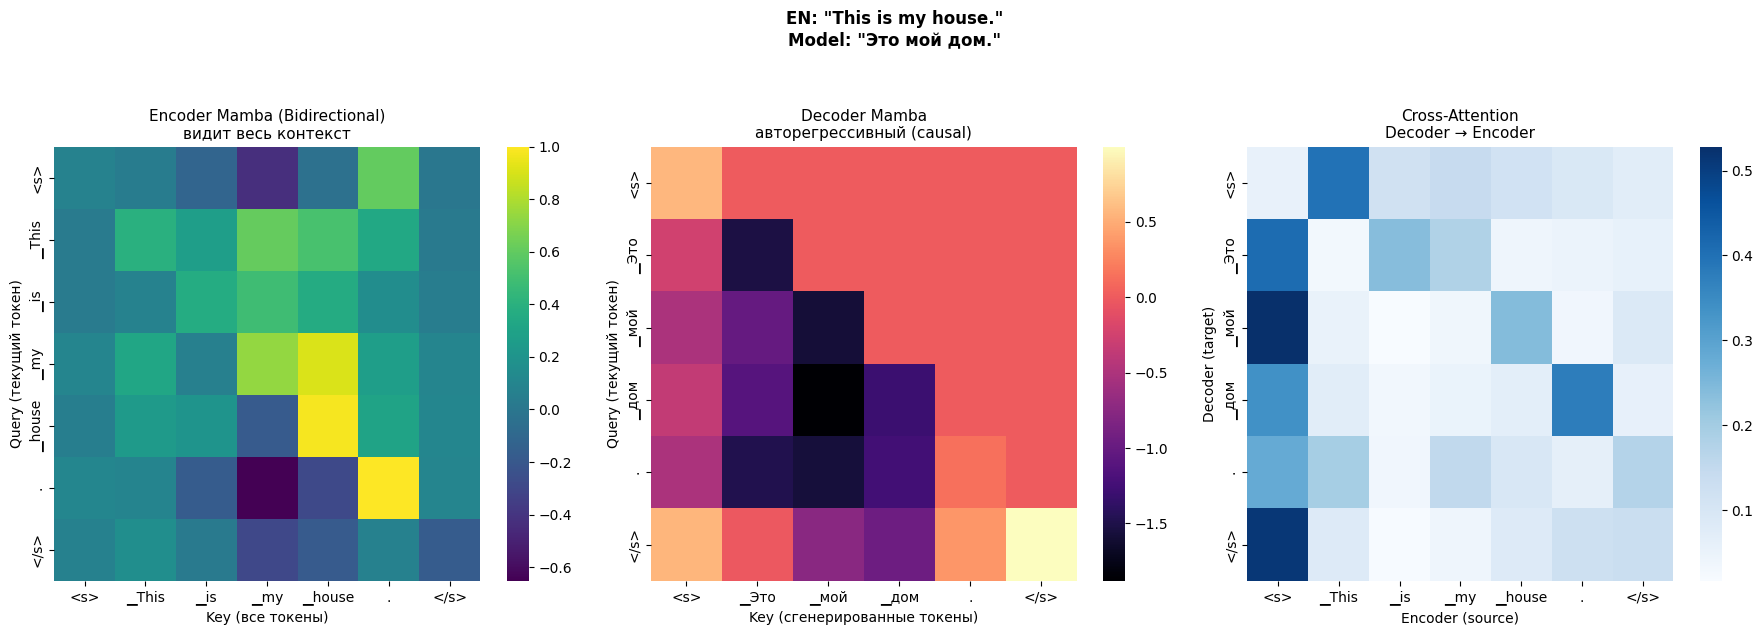

In [16]:
def compute_mamba_attention_map(mamba_block, x):
    B, L, _ = x.shape
    
    proj = mamba_block.in_proj(x)
    
    B_proj = proj[..., 2*mamba_block.d_inner:2*mamba_block.d_inner + mamba_block.n_heads*mamba_block.d_state]
    C_proj = proj[..., 2*mamba_block.d_inner + mamba_block.n_heads*mamba_block.d_state:
                    2*mamba_block.d_inner + 2*mamba_block.n_heads*mamba_block.d_state]
    dt_proj = proj[..., -mamba_block.n_heads:]
    
    B_heads = B_proj.view(B, L, mamba_block.n_heads, mamba_block.d_state)
    C_heads = C_proj.view(B, L, mamba_block.n_heads, mamba_block.d_state)
    dt = F.softplus(dt_proj + mamba_block.dt_bias)
    A = -torch.exp(mamba_block.A_log)
    
    dt_A = dt * A.view(1, 1, -1)
    cumsum = torch.cumsum(dt_A, dim=1)
    diff = cumsum.unsqueeze(2) - cumsum.unsqueeze(1)
    
    causal_mask = torch.tril(torch.ones(L, L, device=x.device, dtype=torch.bool))
    diff = diff.masked_fill(~causal_mask.view(1, L, L, 1), -float('inf'))
    L_matrix = torch.exp(diff)
    
    scores = torch.einsum('bihk,bjhk->bijh', C_heads, B_heads)
    attn_map = scores * L_matrix * dt.unsqueeze(1)
    
    return attn_map[0].detach().cpu()


def compute_cross_attention_map(cross_attn, decoder_hidden, encoder_out):
    B, L_dec, D = decoder_hidden.shape
    L_enc = encoder_out.shape[1]
    
    q = cross_attn.q_proj(decoder_hidden)
    k = cross_attn.k_proj(encoder_out)
    
    q = q.view(B, L_dec, cross_attn.n_heads, cross_attn.d_head).transpose(1, 2)
    k = k.view(B, L_enc, cross_attn.n_heads, cross_attn.d_head).transpose(1, 2)
    
    scores = torch.matmul(q, k.transpose(-2, -1)) * cross_attn.scale
    attn_weights = F.softmax(scores, dim=-1)
    
    return attn_weights[0].detach().cpu()


@torch.no_grad()
def translate_text(model, src_text, sp_en, sp_ru, device='cuda', max_len=64):
    model.eval()
    
    src_ids = [1] + sp_en.encode(src_text, out_type=int)[:max_len-2] + [2]
    src_tensor = torch.tensor([src_ids], device=device)
    src_mask = (src_tensor != 0).float()
    
    encoder_out = model.encode(src_tensor, src_mask)
    generated = [1]
    
    for _ in range(max_len):
        trg_tensor = torch.tensor([generated], device=device)
        logits = model.decode_step(trg_tensor, encoder_out, src_mask)
        next_token = logits[0, -1, :].argmax().item()
        
        if next_token == 2:
            break
        generated.append(next_token)
    
    if len(generated) <= 1:
        return "[EMPTY]"
    
    return sp_ru.decode(generated[1:])


def visualize_attention(model, src_text, trg_text, sp_en, sp_ru, device='cuda'):
    model.eval()

    predicted_translation = translate_text(model, src_text, sp_en, sp_ru, device)
    
    src_ids = [1] + sp_en.encode(src_text, out_type=int)[:30] + [2]
    trg_ids = [1] + sp_ru.encode(trg_text, out_type=int)[:30] + [2]
    
    src_tensor = torch.tensor([src_ids], device=device)
    trg_tensor = torch.tensor([trg_ids], device=device)
    
    src_tokens = [sp_en.id_to_piece(i) for i in src_ids]
    trg_tokens = [sp_ru.id_to_piece(i) for i in trg_ids]
    
    print(f"📥 INPUT (EN):      {src_text}")
    print(f"📤 MODEL OUTPUT:    {predicted_translation}")
    print(f"✅ REFERENCE (RU):  {trg_text}")
    
    with torch.no_grad():
        enc_embed = model.encoder.embedding(src_tensor) * model.encoder.embed_scale
        enc_embed = model.encoder.pos_encoding(enc_embed)
        
        first_enc_layer = model.encoder.layers[0]
        enc_input = first_enc_layer.norm1(enc_embed)
        
        enc_fwd_map = compute_mamba_attention_map(
            first_enc_layer.mamba.mamba_fwd, enc_input
        )
        
        enc_input_rev = torch.flip(enc_input, dims=[1])
        enc_bwd_map = compute_mamba_attention_map(
            first_enc_layer.mamba.mamba_bwd, enc_input_rev
        )
        enc_bwd_map = torch.flip(enc_bwd_map, dims=[0, 1])
        
        enc_combined = enc_fwd_map + enc_bwd_map
        
        enc_out = model.encoder(src_tensor)
        
        # === Decoder ===
        dec_embed = model.decoder.embedding(trg_tensor) * model.decoder.embed_scale
        dec_embed = model.decoder.pos_encoding(dec_embed)
        
        first_dec_layer = model.decoder.layers[0]
        dec_input = first_dec_layer.norm1(dec_embed)
        
        dec_mamba_map = compute_mamba_attention_map(
            first_dec_layer.mamba, dec_input
        )
        
        dec_after_mamba = dec_embed + first_dec_layer.mamba(dec_input)
        dec_normed = first_dec_layer.norm2(dec_after_mamba)
        
        cross_attn_map = compute_cross_attention_map(
            first_dec_layer.cross_attn, dec_normed, enc_out
        )
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    fig.suptitle(f'EN: "{src_text}"\nModel: "{predicted_translation}"', 
                 fontsize=12, fontweight='bold', y=1.05)
    
    # 1. Encoder Mamba (Combined)
    ax1 = axes[0]
    enc_data = enc_combined[:, :, 0].numpy()
    enc_data = enc_data / (enc_data.max() + 1e-8)
    
    sns.heatmap(enc_data, ax=ax1, cmap='viridis',
                xticklabels=src_tokens if len(src_tokens) <= 15 else False,
                yticklabels=src_tokens if len(src_tokens) <= 15 else False)
    ax1.set_title('Encoder Mamba (Bidirectional)\nвидит весь контекст', fontsize=11)
    ax1.set_xlabel('Key (все токены)')
    ax1.set_ylabel('Query (текущий токен)')
    
    # 2. Decoder Mamba
    ax2 = axes[1]
    dec_data = dec_mamba_map[:, :, 0].numpy()
    dec_data = dec_data / (dec_data.max() + 1e-8)
    
    sns.heatmap(dec_data, ax=ax2, cmap='magma',
                xticklabels=trg_tokens if len(trg_tokens) <= 15 else False,
                yticklabels=trg_tokens if len(trg_tokens) <= 15 else False)
    ax2.set_title('Decoder Mamba\nавторегрессивный (causal)', fontsize=11)
    ax2.set_xlabel('Key (сгенерированные токены)')
    ax2.set_ylabel('Query (текущий токен)')
    
    # 3. Cross-Attention
    ax3 = axes[2]
    ca_data = cross_attn_map.mean(dim=0).numpy()
    
    sns.heatmap(ca_data, ax=ax3, cmap='Blues',
                xticklabels=src_tokens if len(src_tokens) <= 15 else False,
                yticklabels=trg_tokens if len(trg_tokens) <= 15 else False)
    ax3.set_title('Cross-Attention\nDecoder → Encoder', fontsize=11)
    ax3.set_xlabel('Encoder (source)')
    ax3.set_ylabel('Decoder (target)')
    
    plt.tight_layout()
    plt.show()
    
    return fig, predicted_translation


test_sentences = [
    ("This is my house.", "Это мой дом.")
]

src, trg = test_sentences[0]
fig, translation = visualize_attention(model, src, trg, sp_en, sp_ru, device=device)

## Выводы

1.  Интерпретация карт внимания
   
   Энкодер:

    Визуализация показывает, что благодаря двунаправленности, токены энкодера имеют доступ к контексту всего предложения.
    
    Например, токен _house получает сильный сигнал от _my и точки, что помогает модели понять всю структуру фразы перед началом перевода.
    
    Яркие участки на карте распределены не только по диагонали, но и захватывают соседние слова справа и слева, то есть, модель видит как прошлое, так и будущее в рамках предложения.

Декодер:
    
    Сильная активация наблюдается, как правило, на предыдущем слове, что говорит о том, что модель активно использует локальный контекст для согласования слов. Хотя иногда может заглянуть и дальше.

Cross-Attention:

    На карте отсутствует диагональное выравнивание. Скорее наблюдается концентрация внимания на первом токене энкодера для всех шагов генерации.
    Видимо модель не использует Cross-Attention для пословного выравнивания. Возможно, энкодер Mamba и так достаточно сжимает всю информацию предложения в начальные токены, и декодеру хватает обращаться только к ним.

2. Как модель воспринимает данные и принимает решения:
   
   Возможно, модель воспринимает входное предложение не как набор отдельных слов, а как цельный сжатый смысл, который она сохраняет в одном векторе. Поэтому у нас в Cross-Attention, так мало активаций. При генерации перевода модель опирается почти только на этот глобальный контекст и соседние предыдущие токены.

    
    


    
    